In [1]:
import duckdb
from functions.evaluation import evaluate
from networks.comment_108 import Comment108Model
from networks.cnn_network import build_dataloader


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT row_id, value, set, fractions,boundaries,interpretation,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,igm,iga,label as raw_label
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()

patterns = ['m-komponent < 1 g/l', 'specifik immunisering', 'lätt avvikande immunglobulinfördelning', 'lätt avavikande immunglobulinfördelning']

def has_valid_text(text):
    text_lower = str(text).lower()
    return any(p in text_lower for p in patterns)

df = df[df['raw_label'].isin([0, 2, 6])].copy()

correct_label = df['raw_label'] == 6
valid_text = df['interpretation'].apply(has_valid_text)

df['label'] = ((correct_label) | (valid_text)).astype(int)


train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.8).index

train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan kommentar 108 i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med kommentar 108 i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

cnn = Comment108Model()
train_dl = build_dataloader(train_rows)
val_dl = build_dataloader(val_rows)
test_dl = build_dataloader(test_rows)
cnn.retrain(train_dl=train_dl,val_dl=val_dl,patience=30)

Antal utan kommentar 108 i träningsdatan: 12060
Antal med kommentar 108 i träningsdatan: 2551
Epoch   0 | train: 0.6264 | val: 0.7805 | acc: 39.05% | AUC: 0.712  | LR: 0.0001
  -> ny bästa modell sparad till ../models/comment_108.pth
Epoch   1 | train: 0.6185 | val: 0.6993 | acc: 53.31% | AUC: 0.725  | LR: 0.0001
  -> ny bästa modell sparad till ../models/comment_108.pth
Epoch   2 | train: 0.6122 | val: 0.6390 | acc: 65.55% | AUC: 0.731  | LR: 0.0001
  -> ny bästa modell sparad till ../models/comment_108.pth
Epoch   3 | train: 0.6048 | val: 0.6164 | acc: 68.89% | AUC: 0.730  | LR: 0.0001
  -> ny bästa modell sparad till ../models/comment_108.pth
Epoch   4 | train: 0.5960 | val: 0.6295 | acc: 65.40% | AUC: 0.759  | LR: 0.0001
Epoch   5 | train: 0.5858 | val: 0.5455 | acc: 78.14% | AUC: 0.779  | LR: 0.0001
  -> ny bästa modell sparad till ../models/comment_108.pth
Epoch   6 | train: 0.5730 | val: 0.5903 | acc: 71.22% | AUC: 0.789  | LR: 0.0001
Epoch   7 | train: 0.5568 | val: 0.7125 | ac

Totala mängd datapunkter: 3301
              precision    recall  f1-score   support

     Negativ       0.99      0.87      0.93      3193
     Positiv       0.17      0.80      0.28       108

    accuracy                           0.87      3301
   macro avg       0.58      0.83      0.61      3301
weighted avg       0.97      0.87      0.91      3301

[[2779  414]
 [  22   86]]
AUC: 0.9193664381575436
Accuracy:  86.79%
FN-rate:   20.37%  (farliga missade fall)
FP-rate:   12.97%  (onödiga larm)
Sensitivitet:   79.63%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   87.03%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9194


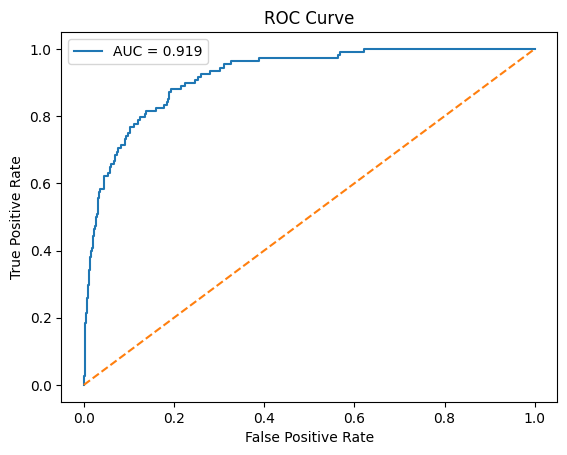

In [2]:
result = cnn.predict(test_rows)
result = cnn.evaluate(val_rows,threshold=0.5)